<a href="https://colab.research.google.com/github/souravnewbee/Blackjack-RL-Agent/blob/main/RL_with_Gymnasium_BlackJack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import jax
import jax.numpy as jnp

# Trick older libraries into finding DeviceArray by pointing it to the new Array class
if not hasattr(jnp, 'DeviceArray'):
    jnp.DeviceArray = jax.Array


In [ ]:
!pip install matplotlib
!pip install numpy
!pip install seaborn
!pip install tqdm
!pip install gymnasium==0.27.0
%matplotlib inline

In [ ]:
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from tqdm import tqdm

import gymnasium as gym


# Let's start by creating the blackjack environment.
# Note: We are going to follow the rules from Sutton & Barto.
# Other versions of the game can be found below for you to experiment.

env = gym.make("Blackjack-v1", sab=True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [ ]:
# Initialize a clean environment without any wrappers
env = gym.make("Blackjack-v1", sab=True)

#observing the environment


In [ ]:
# Reset the environment to get the first observation
done = False
observation, info = env.reset()

# Note that our observation is a tuple consisting of 3 values:

1. The players current sum
2. Value of dealers face-up card
3. Boolean whether the player holds a usable ace
(if it counts 11 without busting)

In [ ]:
# sample a random action from all valid actions
action = env.action_space.sample()
# action=1

# execute the action in our environment and receive infos from the environment
observation, reward, terminated, truncated, info = env.step(action)

# observation=(24, 10, False)
# reward=-1.0
# terminated=True
# truncated=False
# info={}

# if terminated = true, we stop the current episode and begin a new one using env.reset()

In [ ]:
class BlackjackAgent:
    def __init__(
        self,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        """Initialize a Reinforcement Learning agent with an empty dictionary
        of state-action values (q_values), a learning rate and an epsilon.

        Args:
            learning_rate: The learning rate
            initial_epsilon: The initial epsilon value
            epsilon_decay: The decay for epsilon
            final_epsilon: The final epsilon value
            discount_factor: The discount factor for computing the Q-value
        """
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))

        self.lr = learning_rate
        self.discount_factor = discount_factor

        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        self.training_error = []

    def get_action(self, obs: tuple[int, int, bool]) -> int:
        """
        Returns the best action with probability (1 - epsilon)
        otherwise a random action with probability epsilon to ensure exploration.
        """
        # with probability epsilon return a random action to explore the environment
        if np.random.random() < self.epsilon:
            return env.action_space.sample()

        # with probability (1 - epsilon) act greedily (exploit)
        else:
            return int(np.argmax(self.q_values[obs]))

    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        """Updates the Q-value of an action."""
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        temporal_difference = (
            reward + self.discount_factor * future_q_value - self.q_values[obs][action]
        )

        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - epsilon_decay)

q-value function is used to estimate the optimal action to take in each state. it is the one that maximized the long term reward and is given by.



To train the agent, we will let the agent play one episode (one complete
game is called an episode) at a time and then update it’s Q-values after
each episode. The agent will have to experience a lot of episodes to
explore the environment sufficiently.

Now we should be ready to build the training loop.




In [ ]:
# hyperparameters
learning_rate = 0.01
n_episodes = 100_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.1

# Wrap the environment for statistics tracking exactly once
env = gym.wrappers.RecordEpisodeStatistics(env, deque_size=n_episodes)

agent = BlackjackAgent(
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

Info: The current hyperparameters are set to quickly train a decent agent. If you want to converge to the optimal policy, try increasing the n_episodes by 10x and lower the learning_rate (e.g. to 0.001).

In [ ]:

for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False

    # play one episode
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        # update the agent
        agent.update(obs, action, reward, terminated, next_obs)

        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()

  0%|          | 0/100000 [00:00<?, ?it/s]


AttributeError: module 'numpy' has no attribute 'bool8'

In [ ]:
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False

    # play one episode
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        # update the agent
        agent.update(obs, action, reward, terminated, next_obs)

        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()

100%|██████████| 100000/100000 [00:29<00:00, 3338.83it/s]


**Visualizing the training**

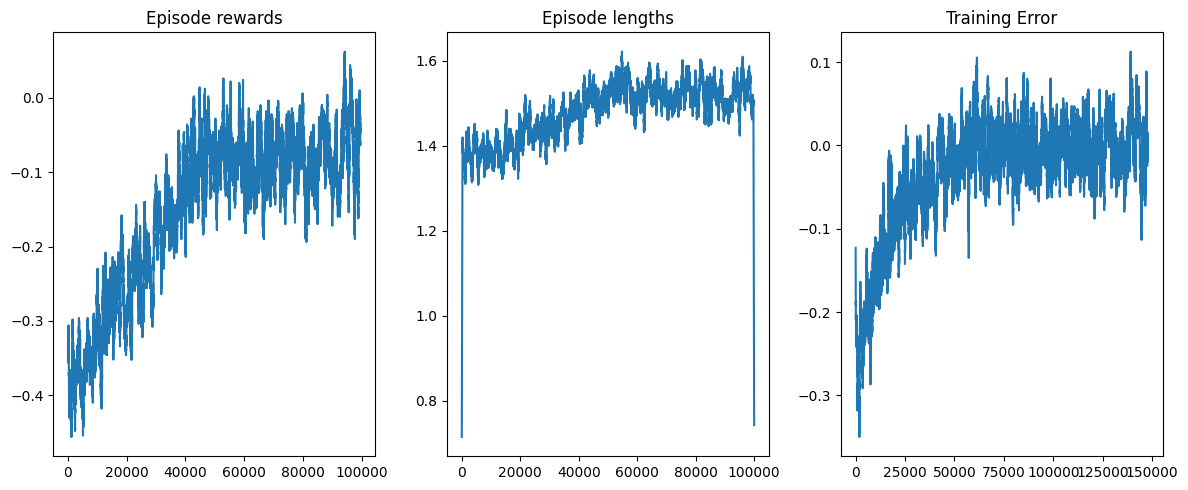

In [ ]:
# This cell (ju-C29iORqCP) itself does not contain the error.
# The `ValueError: Attempted to add episode stats when they already exist` you encountered
# originates from cell NCX6oKhaRpAa.
# It happens because the `gym.wrappers.RecordEpisodeStatistics` is being applied
# to the environment multiple times within the training loop.
# To fix this, you need to remove the line
# `env = gym.wrappers.RecordEpisodeStatistics(env, deque_size=n_episodes)`
# from cell NCX6oKhaRpAa.
# The code below is for plotting and is correct as is.

rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))
axs[0].set_title("Episode rewards")
# compute and assign a rolling average of the data to provide a smoother graph
reward_moving_average = (
    np.convolve(
        np.array(env.return_queue).flatten(), np.ones(rolling_length), mode="valid"
    )
    / rolling_length
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[1].set_title("Episode lengths")
length_moving_average = (
    np.convolve(
        np.array(env.length_queue).flatten(), np.ones(rolling_length), mode="same"
    )
    / rolling_length
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[2].set_title("Training Error")
training_error_moving_average = (
    np.convolve(np.array(agent.training_error), np.ones(rolling_length), mode="same")
    / rolling_length
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
plt.tight_layout()
plt.show()

**Visualising the policy**

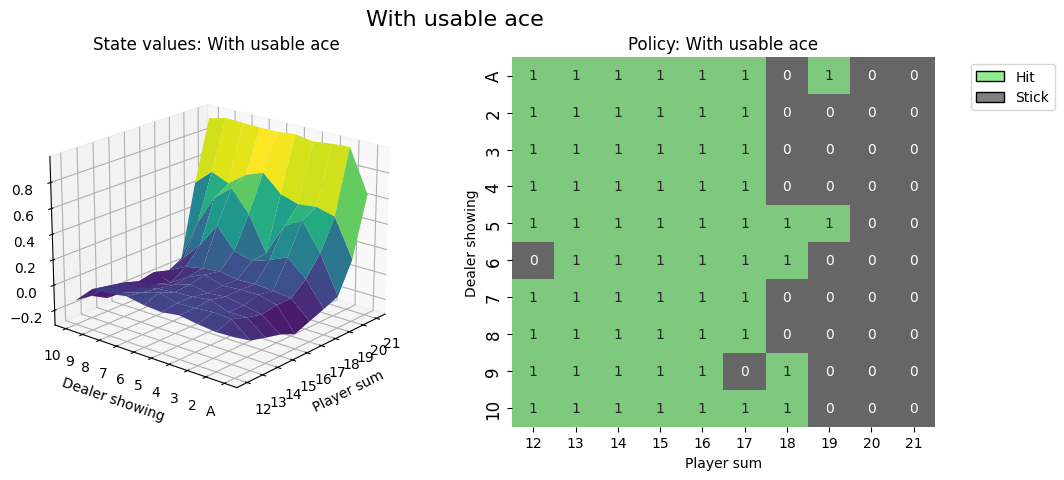

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def create_grids(agent, usable_ace=False):
    """Create value and policy grid given an agent."""
    # convert our state-action values to state values
    # and build a policy dictionary that maps observations to actions
    state_value = defaultdict(float)
    policy = defaultdict(int)
    for obs, action_values in agent.q_values.items():
        state_value[obs] = float(np.max(action_values))
        policy[obs] = int(np.argmax(action_values))

    player_count, dealer_count = np.meshgrid(
        # players count, dealers face-up card
        np.arange(12, 22),
        np.arange(1, 11),
    )

    # create the value grid for plotting
    value = np.apply_along_axis(
        lambda obs: state_value[(obs[0], obs[1], usable_ace)],
        axis=2,
        arr=np.dstack([player_count, dealer_count]),
    )
    value_grid = player_count, dealer_count, value

    # create the policy grid for plotting
    policy_grid = np.apply_along_axis(
        lambda obs: policy[(obs[0], obs[1], usable_ace)],
        axis=2,
        arr=np.dstack([player_count, dealer_count]),
    )
    return value_grid, policy_grid


def create_plots(value_grid, policy_grid, title: str):
    """Creates a plot using a value and policy grid."""
    # create a new figure with 2 subplots (left: state values, right: policy)
    player_count, dealer_count, value = value_grid
    fig = plt.figure(figsize=plt.figaspect(0.4))
    fig.suptitle(title, fontsize=16)

    # plot the state values
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(
        player_count,
        dealer_count,
        value,
        rstride=1,
        cstride=1,
        cmap="viridis",
        edgecolor="none",
    )
    plt.xticks(range(12, 22), range(12, 22))
    plt.yticks(range(1, 11), ["A"] + list(range(2, 11)))
    ax1.set_title(f"State values: {title}")
    ax1.set_xlabel("Player sum")
    ax1.set_ylabel("Dealer showing")
    ax1.zaxis.set_rotate_label(False)
    ax1.set_zlabel("Value", fontsize=14, rotation=90)
    ax1.view_init(20, 220)

    # plot the policy
    fig.add_subplot(1, 2, 2)
    ax2 = sns.heatmap(policy_grid, linewidth=0, annot=True, cmap="Accent_r", cbar=False)
    ax2.set_title(f"Policy: {title}")
    ax2.set_xlabel("Player sum")
    ax2.set_ylabel("Dealer showing")
    ax2.set_xticklabels(range(12, 22))
    ax2.set_yticklabels(["A"] + list(range(2, 11)), fontsize=12)

    # add a legend
    legend_elements = [
        Patch(facecolor="lightgreen", edgecolor="black", label="Hit"),
        Patch(facecolor="grey", edgecolor="black", label="Stick"),
    ]
    ax2.legend(handles=legend_elements, bbox_to_anchor=(1.3, 1))
    return fig


# state values & policy with usable ace (ace counts as 11)
value_grid, policy_grid = create_grids(agent, usable_ace=True)
fig1 = create_plots(value_grid, policy_grid, title="With usable ace")
plt.show()

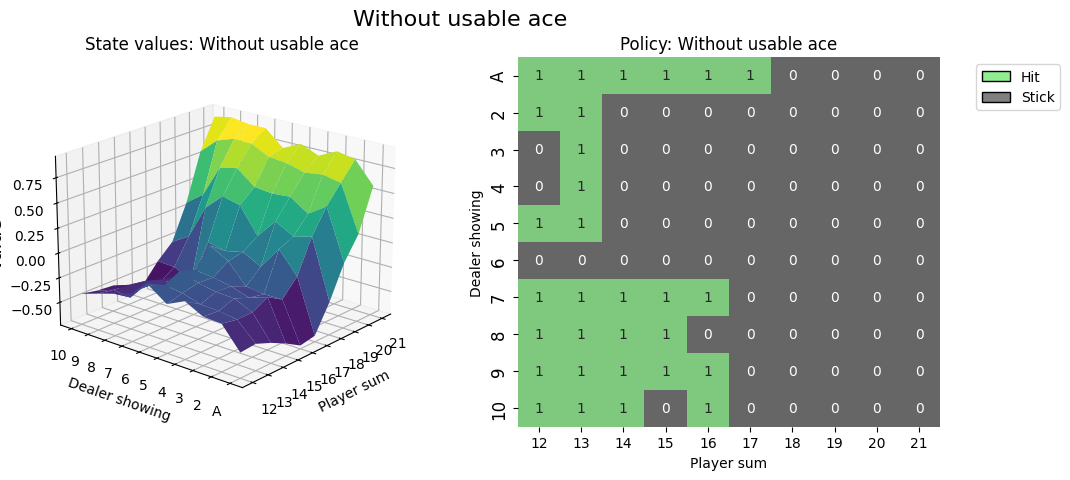

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# state values & policy without usable ace (ace counts as 1)
value_grid, policy_grid = create_grids(agent, usable_ace=False)
fig2 = create_plots(value_grid, policy_grid, title="Without usable ace")
plt.show()

In [ ]:
def visualize_gameplay_emoji(agent, env, n_games=5):
    for i in range(n_games):
        obs, info = env.reset()
        done = False
        print(f"\n{'='*30}\n🃏 GAME {i+1}\n{'='*30}")

        while not done:
            # Use a greedy policy (epsilon=0) for demonstration
            action = int(np.argmax(agent.q_values[obs]))
            strategy = "➕ HIT" if action == 1 else "✋ STICK"

            dealer_card = 'A' if obs[1] == 1 else obs[1]
            ace_status = "✨ Yes" if obs[2] else "❌ No"

            print(f"👤 Player Sum: {obs[0]:<2} | 🎴 Dealer: {dealer_card:<2} | 🃏 Usable Ace: {ace_status}")
            print(f"🤖 Agent Decides: {strategy}")

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            print("-" * 20)

        if reward > 0:
            result = "🎉 PLAYER WINS! 💰"
        elif reward < 0:
            result = "💀 PLAYER LOSES 💸"
        else:
            result = "🤝 PUSH (DRAW) ⚖️"

        print(f"🏁 FINAL SUM: {obs[0]} | RESULT: {result}\n")

# Run the visual gameplay demonstration
visualize_gameplay_emoji(agent, env)


🃏 GAME 1
👤 Player Sum: 13 | 🎴 Dealer: 6  | 🃏 Usable Ace: ❌ No
🤖 Agent Decides: ✋ STICK
--------------------
🏁 FINAL SUM: 13 | RESULT: 💀 PLAYER LOSES 💸


🃏 GAME 2
👤 Player Sum: 12 | 🎴 Dealer: 4  | 🃏 Usable Ace: ❌ No
🤖 Agent Decides: ✋ STICK
--------------------
🏁 FINAL SUM: 12 | RESULT: 🎉 PLAYER WINS! 💰


🃏 GAME 3
👤 Player Sum: 18 | 🎴 Dealer: 2  | 🃏 Usable Ace: ❌ No
🤖 Agent Decides: ✋ STICK
--------------------
🏁 FINAL SUM: 18 | RESULT: 🤝 PUSH (DRAW) ⚖️


🃏 GAME 4
👤 Player Sum: 8  | 🎴 Dealer: 3  | 🃏 Usable Ace: ❌ No
🤖 Agent Decides: ➕ HIT
--------------------
👤 Player Sum: 10 | 🎴 Dealer: 3  | 🃏 Usable Ace: ❌ No
🤖 Agent Decides: ➕ HIT
--------------------
👤 Player Sum: 13 | 🎴 Dealer: 3  | 🃏 Usable Ace: ❌ No
🤖 Agent Decides: ➕ HIT
--------------------
🏁 FINAL SUM: 23 | RESULT: 💀 PLAYER LOSES 💸


🃏 GAME 5
👤 Player Sum: 10 | 🎴 Dealer: 10 | 🃏 Usable Ace: ❌ No
🤖 Agent Decides: ➕ HIT
--------------------
👤 Player Sum: 15 | 🎴 Dealer: 10 | 🃏 Usable Ace: ❌ No
🤖 Agent Decides: ✋ STICK
-----------